Enlace notebook editable:

https://colab.research.google.com/drive/1sfVCmyBLl-VncFaLlrPkL9_EsTclMZNM?usp=sharing

# Paso 1: Generación de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Configuración inicial
np.random.seed(42) # Para reproducibilidad (que siempre genere los mismos datos)
num_registros = 5000 # 5000 registros es un excelente tamaño para entrenar el MVP

# 2. Generación de características base (features)

# Asignamos 80% casas y 20% departamentos
tipo_inmueble = np.random.choice(['Casa', 'Departamento'], size=num_registros, p=[0.8, 0.2])

# Asumimos una distribución poblacional lógica (15% vive en el Norte, 75% en el Centro y 10% en el Sur)
region = np.random.choice(['Norte', 'Centro', 'Sur'], size=num_registros, p=[0.15, 0.75, 0.10])

# La cantidad de equipos depende del tipo de inmueble (lógica de negocio)
cantidad_equipos = np.where(tipo_inmueble == 'Casa',
                            np.random.randint(8, 25, num_registros),  # Casa: 8 a 24 equipos
                            np.random.randint(4, 15, num_registros))  # Departamento: 4 a 14 equipos

# Horas de alto consumo (entre 2 y 6 horas al día)
horas_alto_consumo = np.random.randint(2, 7, num_registros)

# Uso en horario pico (probabilidad del 65% de que sí lo usen)
uso_horario_pico = np.random.choice([True, False], size=num_registros, p=[0.65, 0.35])

# 3. Simulación del consumo eléctrico (kWh)

# Un consumo base lógico según el tamaño del lugar
consumo_base = np.where(tipo_inmueble == 'Casa', 100, 60)

# Sumamos kWh extra al consumo base por necesidad de climatización
ajuste_clima = np.select(
    [region == 'Norte', region == 'Sur'],
    [20, 40], # +20 kWh por AC en el Norte, +40 kWh por calefacción en el Sur
    default=0 # El Centro se queda igual
)
consumo_base = consumo_base + ajuste_clima

# El consumo real es afectado por los equipos, las horas de uso y el horario pico
consumo_kwh = consumo_base + (cantidad_equipos * 7) + (horas_alto_consumo * 5)
consumo_kwh = consumo_kwh + np.where(uso_horario_pico, 25, 0) # Penalización si usa en hora pico

# Agregamos ruido gaussiano para que no sea un cálculo matemático perfecto
consumo_kwh = consumo_kwh + np.random.normal(0, 20, num_registros)
consumo_kwh = np.clip(consumo_kwh, 50, 900).astype(int) # Mantenemos valores lógicos

# 4. Lógica de etiquetado (ground truth)

# Calculamos un "score de ineficiencia" interno para clasificar
# Comparamos el consumo real vs un consumo ideal para esa cantidad de equipos
consumo_ideal = consumo_base + (cantidad_equipos * 4) + 15
ratio_ineficiencia = consumo_kwh / consumo_ideal

score = (ratio_ineficiencia * 40) + (horas_alto_consumo * 2) + np.where(uso_horario_pico, 15, 0)
score += np.random.normal(0, 6, num_registros) # El "ruido" clave para Machine Learning

# Definimos los umbrales de las categorías
condiciones = [
    (score < 62),
    (score >= 62) & (score < 82),
    (score >= 82)
]
categorias = ['Eficiente', 'Moderado', 'Ineficiente']
categoria = np.select(condiciones, categorias, default='Desconocido')

# 5. Creación del DataFrame

df = pd.DataFrame({
    'region': region,
    'tipo_inmueble': tipo_inmueble,
    'cantidad_equipos': cantidad_equipos,
    'horas_alto_consumo': horas_alto_consumo,
    'uso_horario_pico': uso_horario_pico,
    'consumo_kwh': consumo_kwh,
    'categoria': categoria
})

# 6. Mostrar resumen y guardar archivo

# Primeros datos
print("\nPrimeras 5 filas del dataset:\n")
display(df.head())

# Exportar a CSV para que se pueda descargar
df.to_csv('dataset_consumo_energia_G9_T60.csv', index=False)
print("\n¡Archivo 'dataset_consumo_energia_G9_T60.csv' generado con éxito!")


Primeras 5 filas del dataset:



,region,tipo_inmueble,cantidad_equipos,horas_alto_consumo,uso_horario_pico,consumo_kwh,categoria
0,Centro,Casa,11,2,True,208,Moderado
1,Centro,Departamento,5,4,False,97,Eficiente
2,Centro,Casa,23,2,False,295,Moderado
3,Centro,Casa,21,4,True,326,Moderado
4,Centro,Casa,21,3,True,278,Moderado



¡Archivo 'dataset_consumo_energia_G9_T60.csv' generado con éxito!


# Paso 2: Análisis exploratorio de datos (EDA)

In [ ]:
# 1. Exploración de los datos

print("--- 1. Revisión inicial ---")
print("\nInformación del conjunto de datos:\n")
print(df.info())
print("\nValores nulos:\n")
print(df.isnull().sum())
print("\nMedidas estadísticas de variables numéricas:\n")
display(df.describe().round(2))
print("\nMedidas estadísticas de variables numéricas:\n")
display(df.describe(include=['object', 'bool']))
print("\nDistribución porcentual de variables categóricas:\n")
cols_categoricas = df.select_dtypes(include=['object', 'bool']).columns

for col in cols_categoricas:
    distribucion = (df[col].value_counts(normalize=True) * 100).round(1)
    display(distribucion.astype(str) + '%')
    print()

--- 1. Revisión inicial ---

Información del conjunto de datos:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   region              5000 non-null   object
 1   tipo_inmueble       5000 non-null   object
 2   cantidad_equipos    5000 non-null   int64 
 3   horas_alto_consumo  5000 non-null   int64 
 4   uso_horario_pico    5000 non-null   bool  
 5   consumo_kwh         5000 non-null   int64 
 6   categoria           5000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 239.4+ KB
None

Valores nulos:

region                0
tipo_inmueble         0
cantidad_equipos      0
horas_alto_consumo    0
uso_horario_pico      0
consumo_kwh           0
categoria             0
dtype: int64

Medidas estadísticas de variables numéricas:



,cantidad_equipos,horas_alto_consumo,consumo_kwh
count,5000.00,5000.00,5000.00
mean,14.65,4.07,237.33
std,5.44,1.43,56.27
min,4.00,2.00,62.00
25%,10.00,3.00,199.00
50%,14.00,4.00,241.00
75%,19.00,5.00,279.00
max,24.00,6.00,381.00



Medidas estadísticas de variables numéricas:



,region,tipo_inmueble,uso_horario_pico,categoria
count,5000,5000,5000,5000
unique,3,2,2,3
top,Centro,Casa,True,Moderado
freq,3759,4001,3191,2398



Distribución porcentual de variables categóricas:



,proportion
region,
Centro,75.2%
Norte,15.2%
Sur,9.6%


,proportion
tipo_inmueble,
Casa,80.0%
Departamento,20.0%


,proportion
uso_horario_pico,
True,63.8%
False,36.2%


,proportion
categoria,
Moderado,48.0%
Ineficiente,28.2%
Eficiente,23.8%


/tmp/ipykernel_804/2661966352.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='categoria', order=orden_cat,


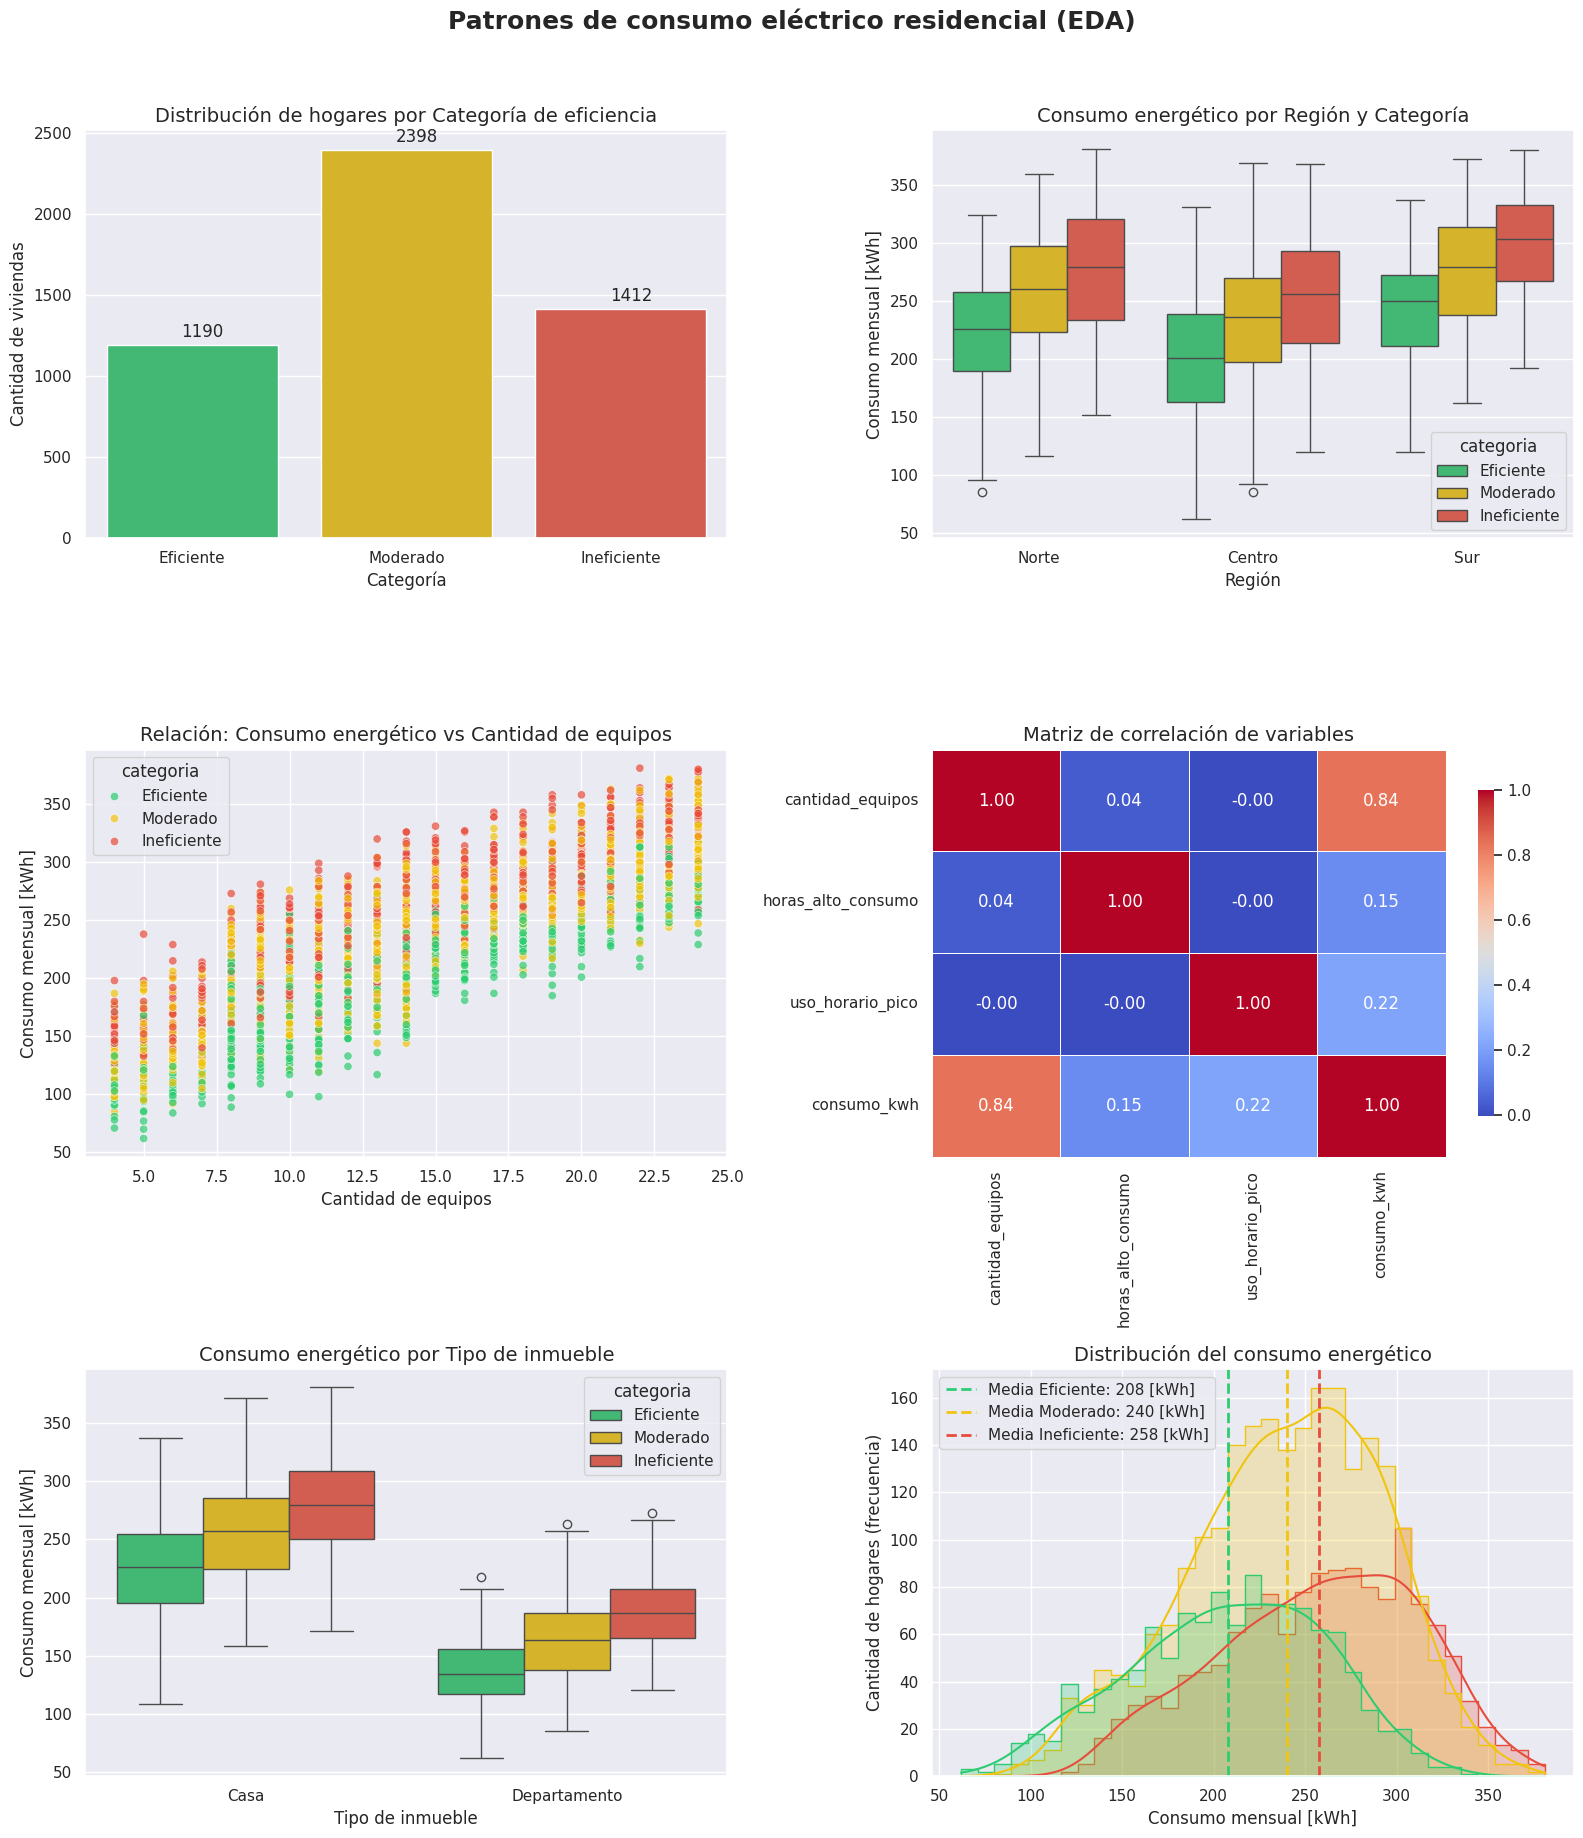

In [ ]:
# 1. Generación de gráficos

# Configuración visual
sns.set_theme(style="darkgrid", palette="muted")

# Configuración de los gráficos
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Patrones de consumo eléctrico residencial (EDA)', fontsize=18, fontweight='bold', y=1.02)

# Diccionario de colores y orden de categorías
colores_dict = {'Eficiente': '#2ecc71', 'Moderado': '#f1c40f', 'Ineficiente': '#e74c3c'}
orden_cat = ['Eficiente', 'Moderado', 'Ineficiente']

# Gráfico 1: Distribución de la variable objetivo (Categoría)
sns.countplot(data=df, x='categoria', order=orden_cat,
              palette=colores_dict, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de hogares por Categoría de eficiencia', fontsize=14)
axes[0, 0].set_ylabel('Cantidad de viviendas')
axes[0, 0].set_xlabel('Categoría')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))

# Gráfico 2: Consumo total vs Región
sns.boxplot(data=df, x='region', y='consumo_kwh', hue='categoria',
            hue_order=orden_cat, palette=colores_dict, order=['Norte', 'Centro', 'Sur'], ax=axes[0, 1])
axes[0, 1].set_title('Consumo energético por Región y Categoría', fontsize=14)
axes[0, 1].set_ylabel('Consumo mensual [kWh]')
axes[0, 1].set_xlabel('Región')

# Gráfico 3: Impacto de la cantidad de equipos en el consumo
sns.scatterplot(data=df, x='cantidad_equipos', y='consumo_kwh', hue='categoria',
                hue_order=orden_cat, palette=colores_dict, alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Relación: Consumo energético vs Cantidad de equipos', fontsize=14)
axes[1, 0].set_ylabel('Consumo mensual [kWh]')
axes[1, 0].set_xlabel('Cantidad de equipos')

# Gráfico 4: Matriz de correlación
df_corr = df.copy()
df_corr['uso_horario_pico'] = df_corr['uso_horario_pico'].astype(int)
matriz_correlacion = df_corr.corr(numeric_only=True)

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, ax=axes[1, 1], cbar_kws={"shrink": .8})
axes[1, 1].set_title('Matriz de correlación de variables', fontsize=14)

# Gráfico 5: Consumo vs Tipo de inmueble (Casa vs Departamento)
sns.boxplot(data=df, x='tipo_inmueble', y='consumo_kwh', hue='categoria',
            hue_order=orden_cat, palette=colores_dict, ax=axes[2, 0])
axes[2, 0].set_title('Consumo energético por Tipo de inmueble', fontsize=14)
axes[2, 0].set_ylabel('Consumo mensual [kWh]')
axes[2, 0].set_xlabel('Tipo de inmueble')

# Gráfico 6: Histograma de consumo (forma y concentración de categorías)
sns.histplot(data=df, x='consumo_kwh', hue='categoria',
             hue_order=orden_cat, palette=colores_dict,
             kde=True, element="step", ax=axes[2, 1])

medias_categoria = df.groupby('categoria')['consumo_kwh'].mean()

for cat in orden_cat:
    media_val = medias_categoria[cat]
    axes[2, 1].axvline(media_val, color=colores_dict[cat], linestyle='--', linewidth=2,
                    label=f'Media {cat}: {media_val:.0f} [kWh]')

axes[2, 1].set_title('Distribución del consumo energético', fontsize=14)
axes[2, 1].set_ylabel('Cantidad de hogares (frecuencia)')
axes[2, 1].set_xlabel('Consumo mensual [kWh]')
axes[2, 1].legend(title='')

# Ajustes generales de gráficos
plt.tight_layout()
plt.show()

# Paso 3: Análisis de patrones de consumo

De acuerdo con lo obtenido en el análisis exploratorio de los datos (EDA), se identificaron los siguientes patrones fundamentales que definen el comportamiento en el consumo energético de los clientes:

1. Contraste del equipamiento

* Gráfico de dispersión y Matriz de correlación.

Existe una correlación positiva fuerte entre la cantidad de equipos y el consumo energético (factor de 0.84 en la matriz de correlación), que en términos absolutos implica que a mayor cantidad de equipos, mayor es el consumo mensual.

No obstante, al desglosar el análisis de acuerdo con las categorías de eficiencia (gráfico de dispersión), se evidencia que tener una alta cantidad de equipos no implica que el inmueble sea ineficiente. Se observan hogares con muchos equipos instalados clasificados como eficientes, así como también hay hogares con pocos equipos clasificados como ineficientes. Esto valida que el sistema de clasificación de eficiencia evalúa el comportamiento energético desde un punto de vista multivariable, no solo considerando la capacidad instalada.

2. Efecto del clima y tipo de inmueble

* Boxplot por región y Boxplot por tipo de inmueble

Las regiones extremas (Norte y Sur) presentan una mediana de consumo más elevadas respecto al Centro (boxplot por región). Este patrón en los datos evidencia la dependencia de sistemas de climatización, ya sea aire acondicionado en el Norte y calefacción eléctrica en el Sur, que elevan consumo energético basal de los hogares.

Por otro lado, los clientes que residen en Casas muestran cuartiles y medianas considerablemente mayores a los que residen en Departamentos (boxplot por tipo de inmueble), lo que sugiere que una mayor superficie construida amplifica el desperdicio energético.

3. Distribución de los datos

* Gráfico de barras e Histograma de consumo

Para todas las categorías, el consumo presenta un comportamiento que se puede asociar a una distribución simétrica con forma de campana (distribución normal), presentando una concentración de frecuencia generalizada en torno al rango de 200 a 300 [kWh] (histograma de consumo), que se puede asimilar a un consumo estándar a nivel residencial. Se observa que las medias de cada grupo se desplazan de manera lógica de acuerdo con el grado de eficiencia, evidenciando una clara diferencia estadística a nivel descriptivo.

Por otro lado, se observa una cantidad representativa en las tres categorías de consumo (gráfico de barras), los datos se ven balanceados y muestran patrones no lineales para definir la categoría de eficiencia (gráfico de dispersión).

Estas características permiten que un modelo de aprendizaje automático tenga datos suficientes en cada categoría para aprender las fronteras de decisión entre ellas de manera adecuada, mitigando el riesgo de subajuste o sobreajuste al predecir la variable objetivo al evaluar nuevos datos.

# Paso 4: Procesamiento y transformación de variables

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [ ]:
# 1. Separar características (X) y variable objetivo (y)
X = df.drop(columns=['categoria'])
y_inicial = df['categoria']

# 2. Mapeo lógico y manual de la variable objetivo (y) que asigna una jerarquía ordenada
mapeo_clases = {'Eficiente': 0, 'Moderado': 1, 'Ineficiente': 2}
y = y_inicial.map(mapeo_clases)

print("Mapeo de clases objetivo aplicado:\n")
for clase, valor in mapeo_clases.items():
    print(f" - {clase}: {valor}")

# 3. Definir columnas categóricas y numéricas/booleanas
var_categoricas = ['region', 'tipo_inmueble']
var_numericas = ['cantidad_equipos', 'horas_alto_consumo', 'uso_horario_pico', 'consumo_kwh']

# 4. Configurar el ColumnTransformer para aplicar OneHotEncoder a las variables de texto
one_hot = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='if_binary', sparse_output=False), var_categoricas),
        ('num', StandardScaler(), var_numericas)
    ],
    remainder='passthrough' # Mantiene intactas las variables numéricas y booleanas
)

# 5. División de datos en conjuntos de entrenamiento (80%) y prueba (20%) con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Ajustar y transformar el conjunto de entrenamiento, y transformar el de prueba
X_train_procesado = one_hot.fit_transform(X_train)
X_test_procesado = one_hot.transform(X_test)

print(f"\nDimensiones de X_train procesado: {X_train_procesado.shape}")
print(f"Dimensiones de X_test procesado: {X_test_procesado.shape}")

Mapeo de clases objetivo aplicado:

 - Eficiente: 0
 - Moderado: 1
 - Ineficiente: 2

Dimensiones de X_train procesado: (4000, 8)
Dimensiones de X_test procesado: (1000, 8)


In [ ]:
# Visualización de los datos transformados

# 1. Variable objetivo (y)
print("Vista de las primeras 5 filas de y_train:")
display(y_train.head())

# 2. Variables explicativas (X)
# Extraemos los nombres de las columnas generadas por el ColumnTransformer
nombres_columnas = one_hot.get_feature_names_out()

# Reconstruir DataFrame temporal para verlo
X_train_df = pd.DataFrame(X_train_procesado, columns=nombres_columnas)

print("\nVista de las primeras 5 filas de X_train procesado:")
display(X_train_df.head())

Vista de las primeras 5 filas de y_train:


,categoria
2717,0
3295,2
2573,1
1391,2
2702,0



Vista de las primeras 5 filas de X_train procesado:


,cat__region_Centro,cat__region_Norte,cat__region_Sur,cat__tipo_inmueble_Departamento,num__cantidad_equipos,num__horas_alto_consumo,num__uso_horario_pico,num__consumo_kwh
0,0.0,0.0,1.0,1.0,-0.112303,-0.750315,-1.323266,-0.911181
1,1.0,0.0,0.0,0.0,-0.663485,0.655757,0.755706,-0.465825
2,1.0,0.0,0.0,0.0,-0.663485,0.655757,0.755706,-0.198611
3,1.0,0.0,0.0,0.0,1.173787,0.655757,0.755706,1.030572
4,1.0,0.0,0.0,0.0,-0.296031,-0.047279,-1.323266,-0.946809


# Paso 5: Entrenamiento de modelos supervisados

## Modelo Dummy (base)

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Accuracy (Exactitud global): 0.380

Métricas: Modelo Dummy (base)

              precision    recall  f1-score   support

   Eficiente       0.24      0.25      0.25       238
    Moderado       0.50      0.50      0.50       480
 Ineficiente       0.29      0.28      0.29       282

    accuracy                           0.38      1000
   macro avg       0.35      0.35      0.35      1000
weighted avg       0.38      0.38      0.38      1000



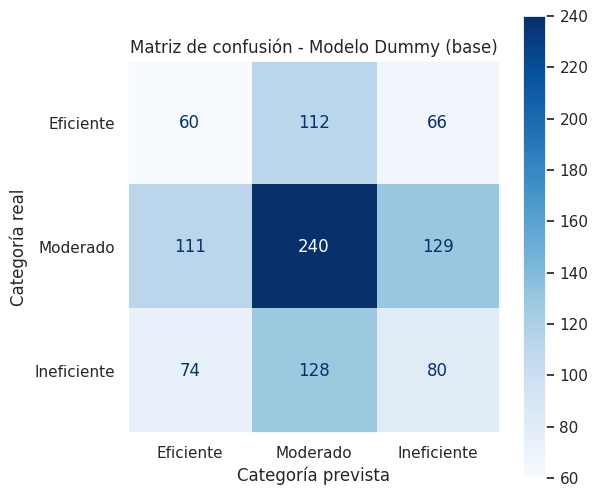

In [ ]:
# 1. Instanciar el Modelo Dummy
# Usamos 'stratified' para que imite la distribución de probabilidad de las clases en el entrenamiento
modelo_dummy = DummyClassifier(strategy='stratified', random_state=42)

# 2. Entrenar el modelo base con los datos procesados
modelo_dummy.fit(X_train_procesado, y_train)

# 3. Predecir sobre el conjunto de prueba
y_pred_dummy = modelo_dummy.predict(X_test_procesado)

# 4. Evaluar el rendimiento general
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
print(f"Accuracy (Exactitud global): {accuracy_dummy:.3f}\n")

# 5. Métricas de rendimiento
print("Métricas: Modelo Dummy (base)\n")
print(classification_report(y_test, y_pred_dummy, target_names=['Eficiente', 'Moderado', 'Ineficiente']))

# 5. Matriz de confusión
mc_dummy = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dummy),
    display_labels=['Eficiente', 'Moderado', 'Ineficiente']
)

fig, ax = plt.subplots(figsize=(6, 6))
mc_dummy.plot(ax=ax, cmap='Blues')
ax.grid(False)
plt.title("Matriz de confusión - Modelo Dummy (base)")
plt.xlabel('Categoría prevista')
plt.ylabel('Categoría real')
plt.show()

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Accuracy (Exactitud global): 0.703

Métricas: Random Forest

              precision    recall  f1-score   support

   Eficiente       0.74      0.85      0.79       238
    Moderado       0.73      0.62      0.67       480
 Ineficiente       0.64      0.72      0.68       282

    accuracy                           0.70      1000
   macro avg       0.70      0.73      0.71      1000
weighted avg       0.71      0.70      0.70      1000



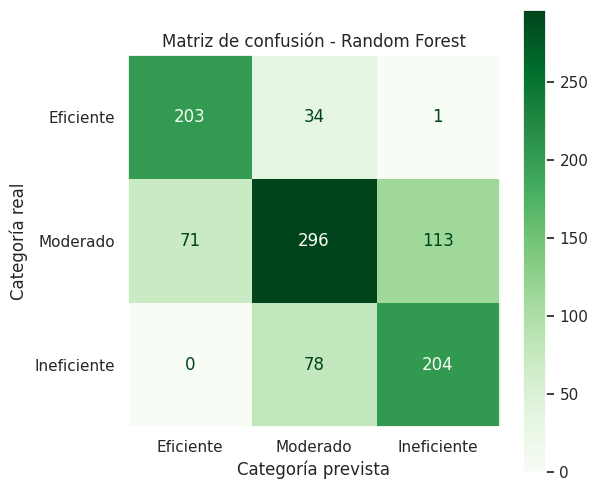

In [ ]:
# 1. Instanciar el Random Forest
modelo_forest = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, class_weight='balanced')

# 2. Entrenar el modelo con los datos procesados
modelo_forest.fit(X_train_procesado, y_train)

# 3. Predecir sobre el conjunto de prueba
y_pred_forest = modelo_forest.predict(X_test_procesado)

# 4. Evaluar el rendimiento general
accuracy_forest = accuracy_score(y_test, y_pred_forest)
print(f"Accuracy (Exactitud global): {accuracy_forest:.3f}\n")

# 5. Métricas de rendimiento
print("Métricas: Random Forest\n")
print(classification_report(y_test, y_pred_forest, target_names=['Eficiente', 'Moderado', 'Ineficiente']))

# 5. Matriz de confusión
mc_rf = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_forest),
    display_labels=['Eficiente', 'Moderado', 'Ineficiente']
)

fig, ax = plt.subplots(figsize=(6, 6))
mc_rf.plot(ax=ax, cmap='Greens')
ax.grid(False)
plt.title("Matriz de confusión - Random Forest")
plt.xlabel('Categoría prevista')
plt.ylabel('Categoría real')
plt.show()

## Regresión logística

In [ ]:
from sklearn.linear_model import LogisticRegression

Accuracy (Exactitud global): 0.705

Métricas: Regresión Logística

              precision    recall  f1-score   support

   Eficiente       0.73      0.87      0.80       238
    Moderado       0.75      0.58      0.65       480
 Ineficiente       0.64      0.77      0.70       282

    accuracy                           0.70      1000
   macro avg       0.71      0.74      0.72      1000
weighted avg       0.71      0.70      0.70      1000



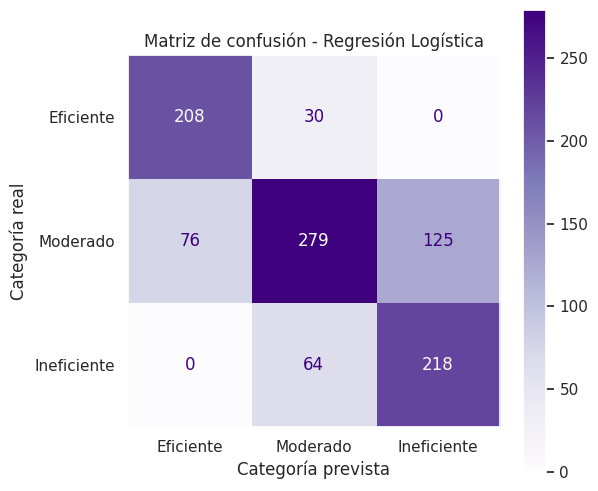

In [ ]:
# 1. Instanciar la Regresión Logística
modelo_log = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# 2. Entrenar el modelo con los datos procesados
modelo_log.fit(X_train_procesado, y_train)

# 3. Predecir sobre el conjunto de prueba
y_pred_log = modelo_log.predict(X_test_procesado)

# 4. Evaluar el rendimiento general
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy (Exactitud global): {accuracy_log:.3f}\n")

# 5. Métricas de rendimiento
print("Métricas: Regresión Logística\n")
print(classification_report(y_test, y_pred_log, target_names=['Eficiente', 'Moderado', 'Ineficiente']))

# 5. Matriz de confusión
mc_log = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_log),
    display_labels=['Eficiente', 'Moderado', 'Ineficiente']
)

fig, ax = plt.subplots(figsize=(6, 6))
mc_log.plot(ax=ax, cmap='Purples')
ax.grid(False)
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel('Categoría prevista')
plt.ylabel('Categoría real')
plt.show()

# Paso 6: Evaluación utilizando métricas adecuadas

In [ ]:
# 1. Agrupar los nombres de los modelos y sus predicciones correspondientes
modelos_dict = {
    'Modelo Dummy (base)': y_pred_dummy,
    'Random Forest': y_pred_forest,
    'Regresión Logística': y_pred_log,
}

filas_resumen = []

# 2. Iterar automáticamente para extraer las métricas de cada modelo
for nombre, y_pred in modelos_dict.items():
  # Calcular accuracy
  acc = accuracy_score(y_test, y_pred)

  # Generar reporte como diccionario (output_dict=True)
  report = classification_report(
      y_test,
      y_pred,
      target_names=['Eficiente', 'Moderado', 'Ineficiente'],
      output_dict=True,
  )

  # Almacenar los valores clave en una fila
  filas_resumen.append({
      'Modelo': nombre,
      'Accuracy': acc,
      'F1-Score (Eficiente)': report['Eficiente']['f1-score'],
      'F1-Score (Moderado)': report['Moderado']['f1-score'],
      'F1-Score (Ineficiente)': report['Ineficiente']['f1-score'],
      'Macro Avg F1-Score': report['macro avg']['f1-score'],
  })

# 3. DataFrame final
df_metricas = pd.DataFrame(filas_resumen)

# 4. Tabla resumen de rendimiento de modelos
print('Tabla resumen de rendimiento de modelos:\n')
print(df_metricas.to_markdown(index=False, floatfmt='.3f'))

Tabla resumen de rendimiento de modelos:

| Modelo              |   Accuracy |   F1-Score (Eficiente) |   F1-Score (Moderado) |   F1-Score (Ineficiente) |   Macro Avg F1-Score |
|:--------------------|-----------:|-----------------------:|----------------------:|-------------------------:|---------------------:|
| Modelo Dummy (base) |      0.380 |                  0.248 |                 0.500 |                    0.287 |                0.345 |
| Random Forest       |      0.703 |                  0.793 |                 0.667 |                    0.680 |                0.713 |
| Regresión Logística |      0.705 |                  0.797 |                 0.654 |                    0.698 |                0.716 |


## Factores críticos de la Regresión Logística

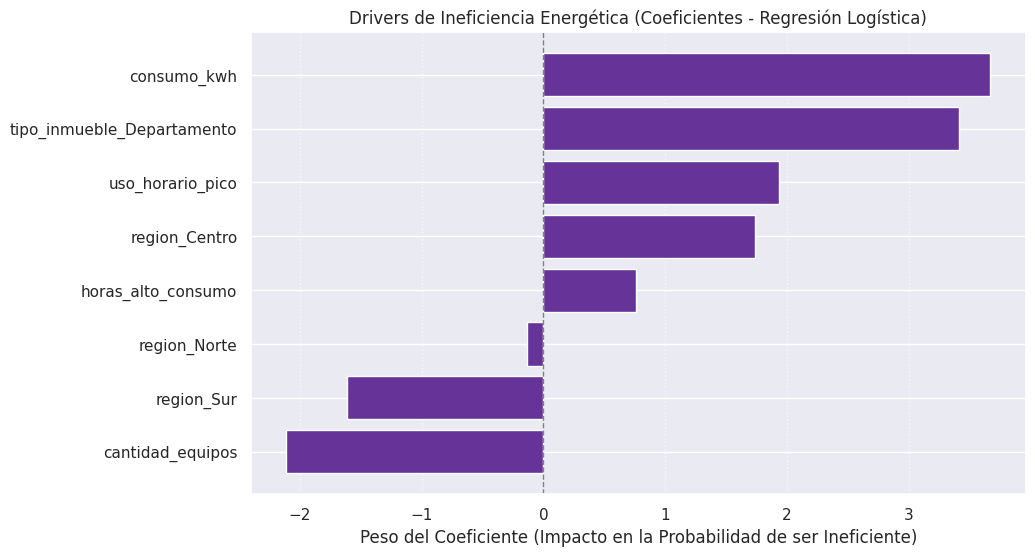

--- TOP VARIABLES QUE DISPARAN LA INEFICIENCIA ---
| Variable                   |   Coeficiente |
|:---------------------------|--------------:|
| consumo_kwh                |      3.6704   |
| tipo_inmueble_Departamento |      3.41215  |
| uso_horario_pico           |      1.93788  |
| region_Centro              |      1.74124  |
| horas_alto_consumo         |      0.761111 |


In [ ]:
# 1. Extraer los nombres de las características transformadas desde el Pipeline/ColumnTransformer
# Obtenemos los nombres de las variables categóricas (One-Hot)
nombres_cat = one_hot.named_transformers_['cat'].get_feature_names_out(var_categoricas)
nombres_num = var_numericas
todas_las_variables = list(nombres_cat) + list(nombres_num)

# 2. Identificar el índice de la clase "Ineficiente" en el modelo
clases_modelo = modelo_log.classes_
idx_ineficiente = list(clases_modelo).index(2)

# 3. Extraer los coeficientes para la clase "Ineficiente"
coeficientes_ineficiente = modelo_log.coef_[idx_ineficiente]

# 4. Crear un DataFrame ordenado para el análisis
df_importancia = pd.DataFrame({
    'Variable': todas_las_variables,
    'Coeficiente': coeficientes_ineficiente
})

# Ordenar de mayor a menor impacto positivo hacia la ineficiencia
df_importancia = df_importancia.sort_values(by='Coeficiente', ascending=False)

# 5. Visualización limpia y profesional
plt.figure(figsize=(10, 6))
# Invertimos el orden para que el más importante quede arriba en el gráfico de barras horizontales
plt.barh(df_importancia['Variable'][::-1], df_importancia['Coeficiente'][::-1], color='rebeccapurple')
plt.title('Drivers de Ineficiencia Energética (Coeficientes - Regresión Logística)')
plt.xlabel('Peso del Coeficiente (Impacto en la Probabilidad de ser Ineficiente)')
plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.show()

# 6. Mostrar la tabla resumen en consola
print("--- TOP VARIABLES QUE DISPARAN LA INEFICIENCIA ---")
print(df_importancia.head(5).to_markdown(index=False))

# Paso 7: Generación de recomendaciones basadas en reglas o modelos

In [ ]:
def predecir_perfil_energetico(datos_usuario, modelo, preprocesador):

    """
    Función para el Backend.
    Recibe un diccionario con los datos del usuario y devuelve el JSON esperado.
    """

    # 1. Convertir la entrada del diccionario a un DataFrame de 1 fila
    df_entrada = pd.DataFrame([datos_usuario])

    # 2. Transformar los datos usando el preprocesador entrenado
    X_procesado = preprocesador.transform(df_entrada)

    # 3. Obtener la predicción y la probabilidad máxima
    categoria_pred = modelo.predict(X_procesado)[0]
    probabilidades = modelo.predict_proba(X_procesado)[0]
    prob_maxima = np.max(probabilidades)

    # 4. Extracción corregida de variables
    tipo_inmueble = datos_usuario.get('tipo_inmueble', '')
    region = datos_usuario.get('region', '')
    uso_pico = bool(datos_usuario.get('uso_horario_pico', False))
    horas_alto_consumo = datos_usuario.get('horas_alto_consumo', 0)
    cantidad_equipos = datos_usuario.get('cantidad_equipos', 0)
    consumo_kwh = datos_usuario.get('consumo_kwh', 0)

    # 5. Generar recomendaciones (motor de reglas)
    recomendaciones = []

    if categoria_pred == 'Ineficiente':
        recomendaciones.append("Atención: Tu perfil de consumo energético se encuentra en la categoría Ineficiente.")

        # Cruce 1: Departamento + Centro (los mayores coeficientes positivos)
        if tipo_inmueble == 'Departamento' and region == 'Centro':
            recomendaciones.append("Detectamos que vives en un departamento en la zona central, que registran un alto riesgo de ineficiencia. Revisa el estado de puertas y ventanas para evitar pérdidas térmicas.")

        # Cruce 2: Uso en horario pico (booleano)
        if uso_pico:
            recomendaciones.append("Registras consumo durante el horario punta de la red. Desplazar el uso de electrodomésticos de mayor potencia fuera de horas de mayor demanda (18:00 a 22:00 horas) te ayudará a reducir el costo del servicio.")

        # Cruce 3: Horas continuas de alto consumo
        if horas_alto_consumo >= 4:
            recomendaciones.append(f"Registras un promedio elevado de horas en alto consumo ({horas_alto_consumo} [horas/día]). Te sugerimos utilizar temporizadores o enchufes inteligentes para gestionar el tiempo de encendido.")

        # Cruce 4: Relación Equipos vs. Consumo
        if cantidad_equipos <= 5 and consumo_kwh > 250:
            recomendaciones.append("Tienes pocos electrodomésticos, pero un consumo eléctrico elevado. Es muy probable que tengas al menos un equipo antiguo o defectuoso que está operando con baja eficiencia energética.")

        # Cruce 5: Regiones extremas
        if region == 'Norte':
            recomendaciones.append("Vives en el Norte. Allí el uso intensivo de aire acondicionado suele elevar el consumo. Optimiza la temperatura en 24 [°C] y refuerza el aislamiento solar en tus ventanas para gestionar mejor su uso.")
        elif region == 'Sur':
            recomendaciones.append("Vives en el sur. Si utilizas calefacción eléctrica, procura complementar con un buen aislamiento térmico en muros y techos para evitar fugas de calor y gestionar mejor su uso.")

    elif categoria_pred == 'Moderado':
        recomendaciones.append("Tu consumo es Moderado. Estás en el promedio, pero tienes margen de mejora.")

        if uso_pico:
            recomendaciones.append("Evitar el horario punta es tu principal oportunidad para migrar a la categoría Eficiente.")

        if horas_alto_consumo >= 4:
            recomendaciones.append("Procura regular el uso continuo de equipos de climatización para estabilizar tu consumo diario.")

    elif categoria_pred == 'Eficiente':
        recomendaciones.append("¡Excelente trabajo! Tu perfil es Eficiente. Continúa con tus buenos hábitos de consumo.")
        if region == 'Sur':
            recomendaciones.append("Mantener buenas prácticas de aislación y uso de energía en el Sur contribuye a la estabilidad de la red local.")

    # 6. Entregable en formato de diccionario/JSON
    entregable_backend = {
        "categoria": str(categoria_pred),
        "probabilidad": float(round(prob_maxima, 4)),
        "recomendaciones": recomendaciones
    }

    return entregable_backend

# Paso 8: Serialización del modelo entrenado

In [ ]:
from sklearn.pipeline import Pipeline
import joblib

## Regresión logística

In [ ]:
# 1. Crear el Pipeline completo (preprocesamiento + modelo)
pipeline_energia = Pipeline(steps=[
    ('preprocesador', one_hot),
    ('modelo', modelo_log)
])

# 2. Entrenar el Pipeline completo con los datos crudos de entrenamiento
pipeline_energia.fit(X_train, y_train)

# 3. Guardar el archivo
nombre_archivo = 'modelo_pipeline_log.joblib'
joblib.dump(pipeline_energia, nombre_archivo)
print(f"¡Modelo serializado y guardado exitosamente como '{nombre_archivo}'!")

¡Modelo serializado y guardado exitosamente como 'modelo_pipeline_log.joblib'!


## Random Forest

In [ ]:
# 1. Crear el Pipeline completo (preprocesamiento + modelo)
pipeline_energia_forest = Pipeline(steps=[
    ('preprocesador', one_hot),
    ('modelo', modelo_forest)
])

# 2. Entrenar el Pipeline completo con los datos crudos de entrenamiento
pipeline_energia_forest.fit(X_train, y_train)

# 3. Guardar el archivo
nombre_archivo_forest = 'modelo_pipeline_forest.joblib'
joblib.dump(pipeline_energia_forest, nombre_archivo_forest)
print(f"¡Modelo serializado y guardado exitosamente como '{nombre_archivo_forest}'!")

¡Modelo serializado y guardado exitosamente como 'modelo_pipeline_forest.joblib'!
